# 02. 모델 학습 v1 — ResNet18 + Triplet Loss (실험 1, 채택)

## 실험 개요

이 노트북은 MinMaxScaler로 전처리한 49,987개 캔들스틱 이미지로 ResNet18을 Triplet Loss로 파인튜닝한다. Anchor-Positive 쌍은 같은 종목의 연속된 패턴(+1/+2/+3주)으로 구성하고, Negative는 Epoch 1~2에서 랜덤, Epoch 3에서 Semi-hard Mining으로 전환한다.

이 실험(실험 1)이 최종 채택 모델이다.

## 학습 결과 요약

| Epoch | Train Loss | Val Loss | Negative 방식 |
|-------|-----------|---------|----------------|
| 1 | 0.007197 | 0.005817 | Random |
| 2 | 0.004771 | **0.005174** | Random — **Best** |
| 3 | 0.004488 | 0.005999 | Semi-hard → Early Stop |

**최종 채택 모델**: `best_model.pth` (Epoch 2, Val Loss **0.005174**)

## 하이퍼파라미터 설정 근거

| 항목 | 값 | 근거 |
|---|---|---|
| 백본 | ResNet18 (pretrained) | 소규모 데이터셋에서 빠른 수렴, ImageNet 특징 전이 |
| 임베딩 차원 | 512 | ResNet18 최종 레이어 출력 그대로 사용 |
| Triplet Loss margin | 0.2 | 유사 패턴 거리 vs 비유사 패턴 거리 간 최소 간격 |
| 배치 크기 | 128 | A100 40GB VRAM 기준 최적 처리량 |
| 학습률 | 0.002 | AdamW + StepLR 조합에서 안정적 수렴 |
| Anchor-Positive 오프셋 | +1/+2/+3주 | 연속 시간 패턴이 유사하다는 가정 |
| Semi-hard 샘플 수 | 3 | I/O 속도와 Mining 품질 간 균형 |
| Early Stopping patience | 2 | Val Loss가 2 Epoch 연속 개선 없으면 조기 종료 |

## 1. 환경 설정 및 라이브러리

필수 라이브러리를 설치하고 불러온다. PyTorch, torchvision, sklearn, mplfinance 등 학습과 전처리에 필요한 패키지를 한 번에 준비한다.

이 노트북은 전처리(01 노트북)부터 학습까지 전 과정을 포함하므로 Colab 세션 하나로 완결된다. Google Colab A100 기준 전처리 5시간 + 학습 1.5시간 = 총 6.5시간이 소요된다.

---

In [ ]:
# 필수 패키지 설치
!pip install yfinance mplfinance -q

import yfinance as yf
import numpy as np
import pandas as pd
import os
import gc
import time
import warnings
from datetime import datetime
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import models

# 시각화
import matplotlib.pyplot as plt
import mplfinance as mpf
from PIL import Image, ImageEnhance

# Google Colab
from google.colab import drive

warnings.filterwarnings('ignore')

print("✅ 라이브러리 임포트 완료")
print(f"✅ PyTorch 버전: {torch.__version__}")
print(f"✅ CUDA 사용 가능: {torch.cuda.is_available()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 6.9 MB/s eta 0:00:00
✅ 라이브러리 임포트 완료
✅ PyTorch 버전: 2.8.0+cu126
✅ CUDA 사용 가능: True


## 2. 경로 설정

Google Drive를 마운트하고 로컬/드라이브 경로를 구분해 설정한다.

전처리된 이미지는 속도가 빠른 Colab 로컬 저장소(`/content/data`)에 두고, 최종 모델만 Google Drive에 저장해 세션이 끊겨도 유지되도록 한다. Google Drive를 거치는 I/O는 로컬 대비 약 100배 느리므로 학습 데이터는 반드시 로컬에 있어야 한다.

---

## 3. 종목 유니버스 정의

NASDAQ 100과 S&P 100의 합집합 172개 종목 리스트를 재정의한다.

전처리 노트북(01)과 동일한 유니버스를 사용해 데이터 일관성을 유지한다.

In [ ]:
# Google Drive 마운트
drive.mount('/content/drive')

# 경로 설정 (로컬 우선!)
GDRIVE_BASE = '/content/drive/MyDrive/Patron'
LOCAL_BASE = '/content/data'

# 전처리 결과는 로컬에 저장
RAW_PATH = f'{LOCAL_BASE}/raw'
PROCESSED_PATH = f'{LOCAL_BASE}/processed'
IMAGE_DIR = f'{LOCAL_BASE}/images'

# 모델은 Google Drive에 저장
MODEL_SAVE_PATH = f'{GDRIVE_BASE}/models'

# 디렉토리 생성
os.makedirs(RAW_PATH, exist_ok=True)
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print("="*60)
print("📁 경로 설정 (로컬 저장 전략)")
print("="*60)
print(f"✅ 로컬 Raw: {RAW_PATH}")
print(f"✅ 로컬 Processed: {PROCESSED_PATH}")
print(f"✅ 로컬 Images: {IMAGE_DIR}")
print(f"✅ GDrive Models: {MODEL_SAVE_PATH}")
print(f"\n💡 전처리 데이터는 로컬에 저장 → 100배 빠름!")
print("="*60)

Mounted at /content/drive
📁 경로 설정 (로컬 저장 전략)
✅ 로컬 Raw: /content/data/raw
✅ 로컬 Processed: /content/data/processed
✅ 로컬 Images: /content/data/images
✅ GDrive Models: /content/drive/MyDrive/Patron/models

💡 전처리 데이터는 로컬에 저장 → 100배 빠름!


## 4. 주봉 데이터 수집

172개 종목의 2020-01-01 이후 주봉 OHLC 데이터를 yfinance로 내려받아 Colab 로컬에 CSV로 저장한다.

Google Drive를 거치지 않고 로컬에 저장하므로 I/O 병목 없이 빠르게 처리된다.

---

## 5. 섹터 정보 수집

172개 종목의 섹터·산업군 정보를 yfinance에서 수집해 로컬에 저장한다. 검색 결과에 메타데이터를 붙이기 위해 필요하다.

In [ ]:
# NASDAQ 100
nasdaq_100 = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META',
    'TSLA', 'PLTR', 'NFLX', 'AMD', 'ASML', 'COST', 'CSCO', 'AZN',
    'MU', 'TMUS', 'SHOP', 'APP', 'PEP', 'LRCX', 'LIN', 'QCOM',
    'PDD', 'INTC', 'ISRG', 'INTU', 'AMAT', 'ARM', 'BKNG', 'AMGN',
    'KLAC', 'PANW', 'GILD', 'TXN', 'ADBE', 'CRWD', 'HON', 'MELI',
    'CEG', 'ADI', 'VRTX', 'DASH', 'ADP', 'CMCSA', 'CDNS', 'SBUX',
    'SNPS', 'MRVL', 'ORLY', 'ABNB', 'MSTR', 'MDLZ', 'CTAS', 'MAR',
    'TRI', 'REGN', 'CSX', 'FTNT', 'MNST', 'PYPL', 'AEP', 'ADSK',
    'WDAY', 'AXON', 'DDOG', 'WBD', 'NXPI', 'ZS', 'ROST', 'PCAR',
    'IDXX', 'EA', 'XEL', 'ROP', 'BKR', 'TTWO', 'FAST', 'EXC',
    'TEAM', 'PAYX', 'CPRT', 'FANG', 'CCEP', 'KDP', 'CTSH', 'GEHC',
    'MCHP', 'VRSK', 'CHTR', 'ODFL', 'KHC', 'CSGP', 'TTD', 'DXCM',
    'BIIB', 'CDW', 'ON', 'LULU', 'GFS'
]

# S&P 100
sp_100 = [
    'NVDA', 'AAPL', 'MSFT', 'GOOGL', 'GOOG', 'AMZN', 'AVGO', 'META',
    'TSLA', 'BRK-B', 'JPM', 'LLY', 'WMT', 'ORCL', 'V', 'MA',
    'XOM', 'PLTR', 'NFLX', 'JNJ', 'AMD', 'COST', 'BAC', 'ABBV',
    'HD', 'PG', 'GE', 'CVX', 'UNH', 'KO', 'CSCO', 'IBM',
    'WFC', 'CAT', 'MS', 'AXP', 'CRM', 'RTX', 'GS', 'TMUS',
    'PM', 'ABT', 'MRK', 'TMO', 'MCD', 'DIS', 'UBER', 'PEP',
    'LIN', 'QCOM', 'NOW', 'ISRG', 'INTC', 'C', 'INTU', 'T',
    'BLK', 'SCHW', 'NEE', 'VZ', 'BKNG', 'AMGN', 'ACN', 'BA',
    'DHR', 'GILD', 'TXN', 'ADBE', 'PFE', 'COF', 'LOW', 'UNP',
    'HON', 'DE', 'MDT', 'LMT', 'COP', 'SO', 'CMCSA', 'CVS',
    'DUK', 'NKE', 'MO', 'BMY', 'GD', 'SBUX', 'MMM', 'AMT',
    'UPS', 'EMR', 'BK', 'MDLZ', 'USB', 'PYPL', 'GM', 'CL',
    'FDX', 'SPG', 'MET', 'AIG'
]

# 합집합 + 지수 추가
all_tickers = list(set(nasdaq_100 + sp_100))
all_tickers.extend(['^IXIC', '^GSPC'])
all_tickers.sort()

print(f"✅ 총 종목 수: {len(all_tickers)}개")
print(f"✅ NASDAQ 100: {len(nasdaq_100)}개")
print(f"✅ S&P 100: {len(sp_100)}개")

✅ 총 종목 수: 172개
✅ NASDAQ 100: 101개
✅ S&P 100: 100개


## 6. 슬라이딩 윈도우 패턴 생성

12주 윈도우로 OHLC 데이터를 잘라 MinMaxScaler로 정규화하고, 메타데이터(종목, 날짜, 수익률)와 함께 저장한다.

---

## 7. 캔들스틱 이미지 생성 (로컬 저장)

약 50,000개 패턴을 224×224 그레이스케일 캔들스틱 이미지로 변환해 Colab 로컬에 `.npy` 파일로 저장한다. 대비 1.5배 강화를 적용해 캔들 형태를 더 선명하게 만든다.

In [ ]:
print(f"🚀 데이터 수집 시작: {len(all_tickers)}개 종목")
print(f"기간: 2020-01-01 ~ {datetime.now().strftime('%Y-%m-%d')}")
print("="*60)

success_count = 0
fail_count = 0
failed_tickers = []

for i, ticker in enumerate(all_tickers, 1):
    try:
        print(f"[{i:3d}/{len(all_tickers)}] {ticker:8s} 다운로드 중...", end=" ")

        data = yf.download(
            ticker,
            start='2020-01-01',
            interval='1wk',
            progress=False,
            auto_adjust=True
        )

        if not data.empty:
            ohlc_data = data[['Open', 'High', 'Low', 'Close']].copy()
            ohlc_data.columns = ['Open', 'High', 'Low', 'Close']

            file_path = f"{RAW_PATH}/{ticker}.csv"
            ohlc_data.index.name = "Date"
            ohlc_data.to_csv(file_path)

            print(f"✅ ({len(ohlc_data):3d}주)")
            success_count += 1
        else:
            print(f"❌ 데이터 없음")
            fail_count += 1
            failed_tickers.append(ticker)

    except Exception as e:
        print(f"❌ 에러: {str(e)[:40]}")
        fail_count += 1
        failed_tickers.append(ticker)

print("\n" + "="*60)
print(f"🎉 수집 완료!")
print(f"✅ 성공: {success_count}개 / ❌ 실패: {fail_count}개")
print("="*60)

🚀 데이터 수집 시작: 172개 종목
기간: 2020-01-01 ~ 2025-11-10
[  1/172] AAPL     다운로드 중... ✅ (306주)
[  2/172] ABBV     다운로드 중... ✅ (306주)
[  3/172] ABNB     다운로드 중... ✅ (257주)
[  4/172] ABT      다운로드 중... ✅ (306주)
[  5/172] ACN      다운로드 중... ✅ (306주)
[  6/172] ADBE     다운로드 중... ✅ (306주)
[  7/172] ADI      다운로드 중... ✅ (306주)
[  8/172] ADP      다운로드 중... ✅ (306주)
[  9/172] ADSK     다운로드 중... ✅ (306주)
[ 10/172] AEP      다운로드 중... ✅ (306주)
[ 11/172] AIG      다운로드 중... ✅ (306주)
[ 12/172] AMAT     다운로드 중... ✅ (306주)
[ 13/172] AMD      다운로드 중... ✅ (306주)
[ 14/172] AMGN     다운로드 중... ✅ (306주)
[ 15/172] AMT      다운로드 중... ✅ (306주)
[ 16/172] AMZN     다운로드 중... ✅ (306주)
[ 17/172] APP      다운로드 중... ✅ (239주)
[ 18/172] ARM      다운로드 중... ✅ (113주)
[ 19/172] ASML     다운로드 중... ✅ (306주)
[ 20/172] AVGO     다운로드 중... ✅ (306주)
[ 21/172] AXON     다운로드 중... ✅ (306주)
[ 22/172] AXP      다운로드 중... ✅ (306주)
[ 23/172] AZN      다운로드 중... ✅ (306주)
[ 24/172] BA       다운로드 중... ✅ (306주)
[ 25/172] BAC      다운로드 중... ✅ (306주)
[

---

---

## 8. 메타데이터 로드 및 Anchor-Positive 쌍 생성

학습에 사용할 Anchor-Positive 쌍을 생성한다. 같은 종목에서 연속된 패턴 i와 i+1, i+2, i+3을 Positive 쌍으로 묶는다.

시간상 인접한 패턴은 **유사한 시장 상황**을 반영하므로 비슷한 형태를 가질 가능성이 높다는 가정에 기반한다. 총 142,221쌍이 생성되며, 이 중 80%가 학습, 20%가 검증에 사용된다.

In [ ]:
print("📊 Sector/Industry 정보 수집 중...")

ticker_info_list = []

for ticker in tqdm(all_tickers, desc="Sector 수집"):
    try:
        info = yf.Ticker(ticker).info
        ticker_info_list.append({
            'ticker': ticker,
            'sector': info.get('sector', 'Unknown'),
            'industry': info.get('industry', 'Unknown')
        })
        time.sleep(0.1)
    except:
        ticker_info_list.append({
            'ticker': ticker,
            'sector': 'Unknown',
            'industry': 'Unknown'
        })

ticker_info_df = pd.DataFrame(ticker_info_list)
ticker_info_df.to_csv(f'{PROCESSED_PATH}/ticker_info.csv', index=False)

print(f"✅ 저장 완료: {PROCESSED_PATH}/ticker_info.csv")

📊 Sector/Industry 정보 수집 중...


Sector 수집: 100%|██████████| 172/172 [00:29<00:00,  5.92it/s]

✅ 저장 완료: /content/data/processed/ticker_info.csv


## 9. 랜덤 Negative 선택 함수

Epoch 1~2에서 사용하는 랜덤 Negative 선택 함수를 정의한다.

Anchor의 3개월 수익률 방향과 반대 방향인 종목에서 Negative를 뽑는다. 상승 Anchor에는 하락 종목의 패턴을, 하락 Anchor에는 상승 종목의 패턴을 Negative로 할당해, 초기 학습부터 모델이 의미 있는 대조를 학습할 수 있게 한다.

---

## 10. ResNet18 임베딩 모델

ResNet18 백본에 1채널 입력과 L2 정규화를 추가해 512차원 임베딩 모델을 구성한다.

컬러 이미지용 3채널 입력을 1채널로 교체한다(흑백 캔들스틱 이미지 대응). 분류 헤드(FC layer)를 제거하고 마지막에 L2 정규화를 적용해 임베딩 벡터가 단위 구면 위에 위치하도록 만든다. 이렇게 하면 L2 거리와 코사인 유사도가 동등해진다.

In [ ]:
print("="*60)
print("🔄 패턴 생성 + 메타데이터")
print("="*60)

WINDOW_SIZE = 12
ticker_info_dict = ticker_info_df.set_index('ticker').to_dict('index')
csv_files = sorted([f for f in os.listdir(RAW_PATH) if f.endswith('.csv')])

all_metadata = []
success_count = 0
total_patterns = 0

for csv_file in tqdm(csv_files, desc="패턴 생성"):
    try:
        ticker = csv_file.replace('.csv', '')
        df = pd.read_csv(f"{RAW_PATH}/{csv_file}", index_col=0)

        sector = ticker_info_dict.get(ticker, {}).get('sector', 'Unknown')
        industry = ticker_info_dict.get(ticker, {}).get('industry', 'Unknown')

        ohlc = df[['Open', 'High', 'Low', 'Close']].values
        patterns = []
        num_patterns = len(ohlc) - WINDOW_SIZE + 1

        for i in range(num_patterns):
            window = ohlc[i:i+WINDOW_SIZE]
            scaler = MinMaxScaler()
            normalized_window = scaler.fit_transform(window)
            patterns.append(normalized_window)

            start_idx = i
            end_idx = i + WINDOW_SIZE - 1
            start_price = df.iloc[start_idx]['Close']
            end_price = df.iloc[end_idx]['Close']

            idx_3m = end_idx + 12
            idx_6m = end_idx + 24
            idx_12m = end_idx + 52

            return_3m = ((df.iloc[idx_3m]['Close'] - end_price) / end_price * 100) if idx_3m < len(df) else None
            return_6m = ((df.iloc[idx_6m]['Close'] - end_price) / end_price * 100) if idx_6m < len(df) else None
            return_1y = ((df.iloc[idx_12m]['Close'] - end_price) / end_price * 100) if idx_12m < len(df) else None

            all_metadata.append({
                'ticker': ticker,
                'pattern_id': i,
                'start_date': df.index[start_idx],
                'end_date': df.index[end_idx],
                'start_price': start_price,
                'end_price': end_price,
                'sector': sector,
                'industry': industry,
                'return_3m': return_3m,
                'return_6m': return_6m,
                'return_1y': return_1y
            })

        patterns_array = np.array(patterns)
        np.save(f"{PROCESSED_PATH}/{ticker}.npy", patterns_array)

        success_count += 1
        total_patterns += len(patterns)

    except Exception as e:
        print(f"\n❌ {ticker} 처리 실패: {e}")

metadata_df = pd.DataFrame(all_metadata)
metadata_df.to_csv(f"{PROCESSED_PATH}/metadata_all.csv", index=False)

print("\n" + "="*60)
print(f"✅ 성공: {success_count}/{len(csv_files)}개")
print(f"📊 총 패턴: {total_patterns:,}개")
print("="*60)

🔄 패턴 생성 + 메타데이터


패턴 생성: 100%|██████████| 172/172 [00:31<00:00,  5.51it/s]



✅ 성공: 172/172개
📊 총 패턴: 49,987개


## 11. Triplet Loss 정의

Triplet Loss를 정의한다. `max(0, d(a,p)² - d(a,n)² + margin)` 공식으로, Anchor가 Positive에는 가깝고 Negative에는 멀어지도록 학습한다.

margin=0.2로 설정해 완전히 분리된 쌍에 대해서는 gradient가 발생하지 않도록 한다. 이렇게 하면 이미 잘 학습된 쌍은 건드리지 않고 어려운 쌍에 집중할 수 있다.

---

---

---

## 12. Semi-hard Negative Mining 함수

Epoch 3에서 사용하는 Semi-hard Negative Mining 함수를 정의한다.

각 Anchor마다 후보 Negative를 3개 샘플링하고 `d(a,p) < d(a,n) < d(a,p) + margin` 조건을 만족하는 "적당히 어려운" Negative를 선택한다. 너무 쉬운 Negative(거리가 매우 먼 경우)는 gradient=0이 되고, 너무 어려운 Negative(Positive보다 가까운 경우)는 학습을 불안정하게 만들기 때문에 중간 지점을 선택하는 것이다.

In [ ]:
def ohlc_to_grayscale_image(ohlc_array, temp_path='/content/temp_chart.png'):
    """OHLC → 224x224 그레이스케일 이미지"""
    try:
        df = pd.DataFrame(ohlc_array, columns=['Open', 'High', 'Low', 'Close'])
        df.index = pd.date_range('2020-01-01', periods=len(df), freq='W')

        mc = mpf.make_marketcolors(
            up='white', down='white',
            edge='white', wick='white',
            volume='white'
        )

        s = mpf.make_mpf_style(
            marketcolors=mc,
            gridstyle='',
            y_on_right=False,
            facecolor='black',
            figcolor='black'
        )

        mpf.plot(
            df, type='candle', style=s,
            savefig=temp_path,
            figsize=(2.24, 2.24),
            axisoff=True,
            closefig=True
        )

        img = Image.open(temp_path).convert('L')
        img_resized = img.resize((224, 224), Image.LANCZOS)
        enhancer = ImageEnhance.Contrast(img_resized)
        img_enhanced = enhancer.enhance(1.5)

        img_array = np.array(img_enhanced, dtype=np.uint8)

        img.close()
        img_resized.close()
        del img, img_resized, img_enhanced, enhancer, df

        if os.path.exists(temp_path):
            os.remove(temp_path)

        return img_array

    except Exception as e:
        return None

print("🚀 이미지 변환 시작 (로컬 저장!)\n")

npy_files = sorted([f for f in os.listdir(PROCESSED_PATH) if f.endswith('.npy')])
total_success = 0
total_fail = 0

with tqdm(total=len(npy_files), desc="🔄 이미지 생성", unit="ticker") as pbar:
    for npy_file in npy_files:
        ticker = npy_file.replace('.npy', '')
        npy_path = os.path.join(PROCESSED_PATH, npy_file)
        patterns = np.load(npy_path)

        for i in range(len(patterns)):
            output_filename = f"{ticker}_{i}.npy"
            output_path = os.path.join(IMAGE_DIR, output_filename)

            pattern = patterns[i]
            img_array = ohlc_to_grayscale_image(pattern)

            if img_array is not None:
                np.save(output_path, img_array)
                total_success += 1
            else:
                total_fail += 1

            if (total_success + total_fail) % 100 == 0:
                gc.collect()

        del patterns
        gc.collect()

        pbar.update(1)
        pbar.set_postfix({'성공': total_success, '실패': total_fail})

print("\n" + "="*60)
print("🎉 이미지 변환 완료!")
print("="*60)
print(f"✅ 성공: {total_success:,}개")
print(f"❌ 실패: {total_fail}개")
print(f"💾 저장 위치: {IMAGE_DIR} (로컬!)")
print("="*60)

🚀 이미지 변환 시작 (로컬 저장!)



🔄 이미지 생성: 100%|██████████| 172/172 [5:02:44<00:00, 105.61s/ticker, 성공=5e+4, 실패=0]


🎉 이미지 변환 완료!
✅ 성공: 49,987개
❌ 실패: 0개
💾 저장 위치: /content/data/images (로컬!)


## 13. TripletDataset 및 Train/Val 분할

TripletDataset을 정의하고 80/20 비율로 학습/검증 세트를 나눈다.

142,221쌍 중 113,776쌍이 학습, 28,445쌍이 검증에 사용된다. 로컬 저장소에서 직접 이미지를 읽어 Google Drive를 거치지 않으므로 DataLoader I/O 병목이 없다.

---

## 14. 하이퍼파라미터 및 옵티마이저 설정

배치 크기 128, 최대 3 Epoch, 학습률 0.002 등 하이퍼파라미터를 설정하고 DataLoader, AdamW 옵티마이저, StepLR 스케줄러, Mixed Precision GradScaler를 초기화한다.

Mixed Precision(FP16)을 사용하면 A100에서 약 1.5~2배 빠른 연산이 가능하며 VRAM 사용량도 절반으로 줄어든다.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 사용 디바이스: {device}")

if torch.cuda.is_available():
    print(f"✅ GPU 이름: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.cuda.empty_cache()
    gc.collect()
else:
    print("⚠️ GPU 없음! Runtime → Change runtime type → GPU 선택하세요!")

🔥 사용 디바이스: cuda
✅ GPU 이름: NVIDIA A100-SXM4-40GB
✅ GPU 메모리: 42.47 GB


## 15. 학습 루프 실행

3 Epoch 학습 루프를 실행한다. Epoch 1~2는 랜덤 Negative, Epoch 3은 Semi-hard Mining을 사용하고, Val Loss 기준으로 최적 모델을 `best_model.pth`로 저장한다. Early Stopping patience=2를 적용해 Val Loss가 개선되지 않으면 조기 종료한다.

**실행 결과**: Epoch 2에서 Val Loss 0.005174로 최저치를 기록하고, Epoch 3에서 Semi-hard 전환 후 Val Loss가 0.005999로 상승해 Early Stopping이 발동된다.

---

## 16. Loss 그래프 시각화

Epoch별 학습/검증 Loss를 그래프로 그리고 저장한다.

Epoch 2에서 Val Loss가 최저(0.005174)를 기록하고 Epoch 3에서 상승하는 패턴을 볼 수 있다. Semi-hard Mining 전환 후 각 배치당 연산량이 증가해 학습 속도가 느려지고, 동시에 더 어려운 Negative로 인해 Loss가 일시적으로 상승하는 것은 일반적인 현상이다.

In [ ]:
# 메타데이터 로드
metadata = pd.read_csv(f'{PROCESSED_PATH}/metadata_all.csv')
metadata = metadata.dropna(subset=['return_3m'])

print(f"📊 총 패턴 수: {len(metadata):,}개")
print(f"📊 종목 수: {metadata['ticker'].nunique()}개")

# Anchor-Positive 쌍 생성
print("\n🔄 Anchor-Positive 쌍 생성 중...")

anchor_positive_pairs = []

for ticker in tqdm(metadata['ticker'].unique(), desc="종목별 처리"):
    ticker_data = metadata[metadata['ticker'] == ticker].sort_values('pattern_id')

    for i in range(len(ticker_data) - 3):
        anchor_idx = ticker_data.iloc[i].name

        for j in [1, 2, 3]:
            positive_idx = ticker_data.iloc[i + j].name
            anchor_positive_pairs.append({
                'anchor_idx': anchor_idx,
                'positive_idx': positive_idx
            })

anchor_positive_pairs = pd.DataFrame(anchor_positive_pairs)
print(f"\n✅ 총 {len(anchor_positive_pairs):,}개 Anchor-Positive 쌍 생성")

📊 총 패턴 수: 47,923개
📊 종목 수: 172개

🔄 Anchor-Positive 쌍 생성 중...


종목별 처리: 100%|██████████| 172/172 [00:07<00:00, 21.92it/s]



✅ 총 142,221개 Anchor-Positive 쌍 생성


---

---

---

In [ ]:
def get_initial_negative(anchor_idx, metadata, return_threshold=5):
    """반대 수익률 기준으로 Random Negative 선택"""
    anchor = metadata.loc[anchor_idx]
    anchor_return = anchor['return_3m']
    anchor_ticker = anchor['ticker']

    if anchor_return > 0:
        neg_pool = metadata[
            (metadata['return_3m'] < -return_threshold) &
            (metadata['ticker'] != anchor_ticker)
        ]
    else:
        neg_pool = metadata[
            (metadata['return_3m'] > return_threshold) &
            (metadata['ticker'] != anchor_ticker)
        ]

    if len(neg_pool) == 0:
        neg_pool = metadata[metadata['ticker'] != anchor_ticker]

    return np.random.choice(neg_pool.index)

print("✅ Negative 선택 함수 정의 완료")

✅ Negative 선택 함수 정의 완료


---

ResNet18 백본에 1채널 입력과 L2 정규화를 추가해 512차원 임베딩 모델을 만듭니다. 분류 헤드를 제거하고 마지막에 L2 정규화를 적용해 코사인 거리로 유사도를 비교할 수 있게 합니다.

In [ ]:
class ChartEmbeddingModel(nn.Module):
    def __init__(self, embedding_dim=512):
        super(ChartEmbeddingModel, self).__init__()

        resnet = models.resnet18(pretrained=True)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.embedding_dim = embedding_dim

    def forward(self, x):
        features = self.features(x)
        embeddings = features.view(features.size(0), -1)
        embeddings = F.normalize(embeddings, p=2, dim=1)
        return embeddings

model = ChartEmbeddingModel(embedding_dim=512).to(device)
print(f"✅ ResNet18 모델 생성 완료")
print(f"✅ 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 244MB/s]


✅ ResNet18 모델 생성 완료
✅ 파라미터 수: 11,170,240


---

---

In [ ]:
class TripletLoss(nn.Module):
    def __init__(self, margin=0.2):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        dist_ap = torch.sum((anchor - positive) ** 2, dim=1)
        dist_an = torch.sum((anchor - negative) ** 2, dim=1)
        losses = torch.relu(dist_ap - dist_an + self.margin)
        return losses.mean()

criterion = TripletLoss(margin=0.2)
print("✅ Triplet Loss 정의 완료")

✅ Triplet Loss 정의 완료


---

---

In [ ]:
!rm -f /content/data/images.tar
!tar -cf /content/data/images.tar -C /content/data images/
!ls -lh /content/data/images.tar

-rw-r--r-- 1 root root 2.4G Nov 11 05:57 /content/data/images.tar


In [ ]:
# Google Drive로 복사
!cp /content/data/images.tar /content/drive/MyDrive/Patron/

  # 확인
!ls -lh /content/drive/MyDrive/Patron/images.tar

-rw------- 1 root root 2.4G Nov 11 06:02 /content/drive/MyDrive/Patron/images.tar


In [ ]:
def find_semi_hard_negative_batch(anchor_emb, positive_emb, batch_indices, metadata, model, device, margin=0.2, sample_size=3):
    """배치 단위 Semi-hard Negative Mining"""
    batch_size = len(anchor_emb)
    negative_indices = []
    dist_ap = torch.sum((anchor_emb - positive_emb) ** 2, dim=1).detach().cpu().numpy()

    for i in range(batch_size):
        anchor_idx = batch_indices[i]
        anchor_meta = metadata.loc[anchor_idx]
        anchor_single = anchor_emb[i]
        dist_ap_single = dist_ap[i]

        neg_pool = metadata[metadata['ticker'] != anchor_meta['ticker']]

        if len(neg_pool) > sample_size:
            neg_pool = neg_pool.sample(n=sample_size)

        candidate_embeddings = []
        candidate_indices = []

        for idx in neg_pool.index:
            try:
                img_path = f"{IMAGE_DIR}/{metadata.loc[idx]['ticker']}_{metadata.loc[idx]['pattern_id']}.npy"
                img = np.load(img_path)
                img_tensor = torch.FloatTensor(img).unsqueeze(0).unsqueeze(0).to(device) / 255.0

                with torch.no_grad():
                    emb = model(img_tensor).squeeze(0)

                candidate_embeddings.append(emb)
                candidate_indices.append(idx)
            except:
                continue

        if len(candidate_embeddings) == 0:
            negative_indices.append(neg_pool.index[0])
            continue

        candidate_embeddings = torch.stack(candidate_embeddings)
        dist_an = torch.sum((anchor_single.unsqueeze(0) - candidate_embeddings) ** 2, dim=1)

        semi_hard_mask = (dist_an > dist_ap_single) & (dist_an < dist_ap_single + margin)
        semi_hard_indices = torch.where(semi_hard_mask)[0]

        if len(semi_hard_indices) > 0:
            selected = np.random.choice(semi_hard_indices.cpu().numpy())
            negative_indices.append(candidate_indices[selected])
        else:
            hardest = dist_an.argmin().item()
            negative_indices.append(candidate_indices[hardest])

    return negative_indices

print("✅ Semi-hard Negative Mining 함수 정의 완료")

✅ Semi-hard Negative Mining 함수 정의 완료


---

---

In [ ]:
class TripletDataset(Dataset):
    """로컬에서 직접 읽기 - 100배 빠름!"""
    def __init__(self, anchor_positive_pairs, metadata, image_dir):
        self.pairs = anchor_positive_pairs
        self.metadata = metadata
        self.image_dir = image_dir

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        try:
            anchor_idx = self.pairs.iloc[idx]['anchor_idx']
            positive_idx = self.pairs.iloc[idx]['positive_idx']

            anchor_meta = self.metadata.loc[anchor_idx]
            positive_meta = self.metadata.loc[positive_idx]

            anchor_path = f"{self.image_dir}/{anchor_meta['ticker']}_{anchor_meta['pattern_id']}.npy"
            positive_path = f"{self.image_dir}/{positive_meta['ticker']}_{positive_meta['pattern_id']}.npy"

            anchor_img = np.load(anchor_path)
            positive_img = np.load(positive_path)

            anchor_tensor = torch.FloatTensor(anchor_img).unsqueeze(0) / 255.0
            positive_tensor = torch.FloatTensor(positive_img).unsqueeze(0) / 255.0

            return anchor_tensor, positive_tensor, anchor_idx

        except Exception as e:
            dummy = torch.zeros(1, 224, 224)
            return dummy, dummy, 0

# Train/Val Split
print("🔄 Train/Val Split 수행 중...")

train_pairs, val_pairs = train_test_split(
    anchor_positive_pairs,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_dataset = TripletDataset(train_pairs, metadata, IMAGE_DIR)
val_dataset = TripletDataset(val_pairs, metadata, IMAGE_DIR)

print(f"✅ Train: {len(train_dataset):,}개 쌍")
print(f"✅ Val:   {len(val_dataset):,}개 쌍")
print(f"✅ 로컬 저장소에서 읽기 (100배 빠름!)")

🔄 Train/Val Split 수행 중...
✅ Train: 113,776개 쌍
✅ Val:   28,445개 쌍
✅ 로컬 저장소에서 읽기 (100배 빠름!)


---

---

In [ ]:
# 하이퍼파라미터 (3-4시간 완주 버전)
BATCH_SIZE = 128
NUM_EPOCHS = 3
LEARNING_RATE = 0.002
MARGIN = 0.2
SEMI_HARD_SAMPLE_SIZE = 3
WEIGHT_DECAY = 0.01

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
scaler = GradScaler()

print("="*70)
print("📋 학습 설정 (3-4시간 완주 버전)")
print("="*70)
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"배치 크기: {BATCH_SIZE}")
print(f"에폭 수: {NUM_EPOCHS}")
print(f"학습률: {LEARNING_RATE}")
print(f"Semi-hard 샘플: {SEMI_HARD_SAMPLE_SIZE}")
print(f"Train 배치 수: {len(train_loader):,}")
print(f"Val 배치 수: {len(val_loader):,}")
print(f"\n⚡ 최적화:")
print(f"  - Epoch 1-2: Random Negative (빠름!)")
print(f"  - Epoch 3: Semi-hard (정교함!)")
print(f"  - 로컬 디스크 읽기 (100배 빠름!)")
print(f"  - 예상 시간: 2-3시간")
print("="*70)

📋 학습 설정 (3-4시간 완주 버전)
GPU: NVIDIA A100-SXM4-40GB
배치 크기: 128
에폭 수: 3
학습률: 0.002
Semi-hard 샘플: 3
Train 배치 수: 889
Val 배치 수: 223

⚡ 최적화:
  - Epoch 1-2: Random Negative (빠름!)
  - Epoch 3: Semi-hard (정교함!)
  - 로컬 디스크 읽기 (100배 빠름!)
  - 예상 시간: 2-3시간


---

---

In [ ]:
class EarlyStopping:
    def __init__(self, patience=2, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                return True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return False

early_stopping = EarlyStopping(patience=2, min_delta=0.001)
train_losses = []
val_losses = []
best_loss = float('inf')

print("\n" + "="*80)
print("🚀 학습 시작!")
print("="*80 + "\n")

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    # Training
    model.train()
    epoch_loss = 0.0
    batch_count = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]", ncols=100)

    for batch_idx, (anchor_imgs, positive_imgs, anchor_indices) in enumerate(pbar):
        anchor_imgs = anchor_imgs.to(device)
        positive_imgs = positive_imgs.to(device)

        with autocast():
            anchor_emb = model(anchor_imgs)
            positive_emb = model(positive_imgs)

            # Epoch 1-2: Random, Epoch 3: Semi-hard
            if epoch < 2:
                negative_indices = [get_initial_negative(idx, metadata) for idx in anchor_indices.numpy()]
            else:
                negative_indices = find_semi_hard_negative_batch(
                    anchor_emb, positive_emb, anchor_indices.numpy(),
                    metadata, model, device,
                    margin=MARGIN, sample_size=SEMI_HARD_SAMPLE_SIZE
                )

            negative_imgs = []
            for neg_idx in negative_indices:
                neg_meta = metadata.loc[neg_idx]
                neg_path = f"{IMAGE_DIR}/{neg_meta['ticker']}_{neg_meta['pattern_id']}.npy"
                neg_img = np.load(neg_path)
                neg_tensor = torch.FloatTensor(neg_img).unsqueeze(0) / 255.0
                negative_imgs.append(neg_tensor)

            negative_imgs = torch.stack(negative_imgs).to(device)
            negative_emb = model(negative_imgs)

            loss = criterion(anchor_emb, positive_emb, negative_emb)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        batch_count += 1

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg': f'{epoch_loss/batch_count:.4f}'})

        if batch_idx % 100 == 0:
            torch.cuda.empty_cache()

    avg_train_loss = epoch_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [VAL]  ", ncols=100)

        for anchor_imgs, positive_imgs, anchor_indices in val_pbar:
            anchor_imgs = anchor_imgs.to(device)
            positive_imgs = positive_imgs.to(device)

            with autocast():
                anchor_emb = model(anchor_imgs)
                positive_emb = model(positive_imgs)

                if epoch < 2:
                    negative_indices = [get_initial_negative(idx, metadata) for idx in anchor_indices.numpy()]
                else:
                    negative_indices = find_semi_hard_negative_batch(
                        anchor_emb, positive_emb, anchor_indices.numpy(),
                        metadata, model, device,
                        margin=MARGIN, sample_size=SEMI_HARD_SAMPLE_SIZE
                    )

                negative_imgs = []
                for neg_idx in negative_indices:
                    neg_meta = metadata.loc[neg_idx]
                    neg_path = f"{IMAGE_DIR}/{neg_meta['ticker']}_{neg_meta['pattern_id']}.npy"
                    neg_img = np.load(neg_path)
                    neg_tensor = torch.FloatTensor(neg_img).unsqueeze(0) / 255.0
                    negative_imgs.append(neg_tensor)

                negative_imgs = torch.stack(negative_imgs).to(device)
                negative_emb = model(negative_imgs)

                loss = criterion(anchor_emb, positive_emb, negative_emb)

            val_loss += loss.item()
            val_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg': f'{val_loss/(val_pbar.n+1):.4f}'})

    avg_val_loss = val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    scheduler.step()

    epoch_time = time.time() - epoch_start_time

    print("\n" + "="*80)
    print(f"📊 Epoch {epoch+1}/{NUM_EPOCHS} 완료 (소요 시간: {epoch_time/60:.1f}분)")
    print("="*80)
    print(f"🔵 Train Loss: {avg_train_loss:.6f}")
    print(f"🔴 Val Loss:   {avg_val_loss:.6f}")
    print(f"📉 Loss 차이:  {abs(avg_train_loss - avg_val_loss):.6f}")

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
        }, f"{MODEL_SAVE_PATH}/best_model.pth")
        print(f"💾 ✅ Best 모델 저장! (Val Loss: {best_loss:.6f})")

    if early_stopping(avg_val_loss):
        print(f"\n🛑 학습 조기 종료! (Epoch {epoch+1})")
        break

    torch.cuda.empty_cache()
    gc.collect()
    print("="*80 + "\n")

print("\n" + "="*80)
print("🎉 학습 완료!")
print("="*80)
print(f"📊 Best Val Loss: {best_loss:.6f}")
print(f"📊 Final Train Loss: {train_losses[-1]:.6f}")
print(f"📊 Final Val Loss: {val_losses[-1]:.6f}")
print("="*80)


🚀 학습 시작!



Epoch 1/3 [VAL]  : 100%|█████████████████| 223/223 [03:13<00:00,  1.15it/s, loss=0.0031, avg=0.0058]



📊 Epoch 1/3 완료 (소요 시간: 17.4분)
🔵 Train Loss: 0.007197
🔴 Val Loss:   0.005817
📉 Loss 차이:  0.001380
💾 ✅ Best 모델 저장! (Val Loss: 0.005817)



Epoch 2/3 [VAL]  : 100%|█████████████████| 223/223 [03:13<00:00,  1.15it/s, loss=0.0000, avg=0.0052]



📊 Epoch 2/3 완료 (소요 시간: 17.4분)
🔵 Train Loss: 0.004771
🔴 Val Loss:   0.005174
📉 Loss 차이:  0.000403
💾 ✅ Best 모델 저장! (Val Loss: 0.005174)



Epoch 3/3 [VAL]  : 100%|█████████████████| 223/223 [09:48<00:00,  2.64s/it, loss=0.0050, avg=0.0060]


📊 Epoch 3/3 완료 (소요 시간: 54.3분)
🔵 Train Loss: 0.004488
🔴 Val Loss:   0.005999
📉 Loss 차이:  0.001512

🛑 학습 조기 종료! (Epoch 3)

🎉 학습 완료!
📊 Best Val Loss: 0.005174
📊 Final Train Loss: 0.004488
📊 Final Val Loss: 0.005999


---

---

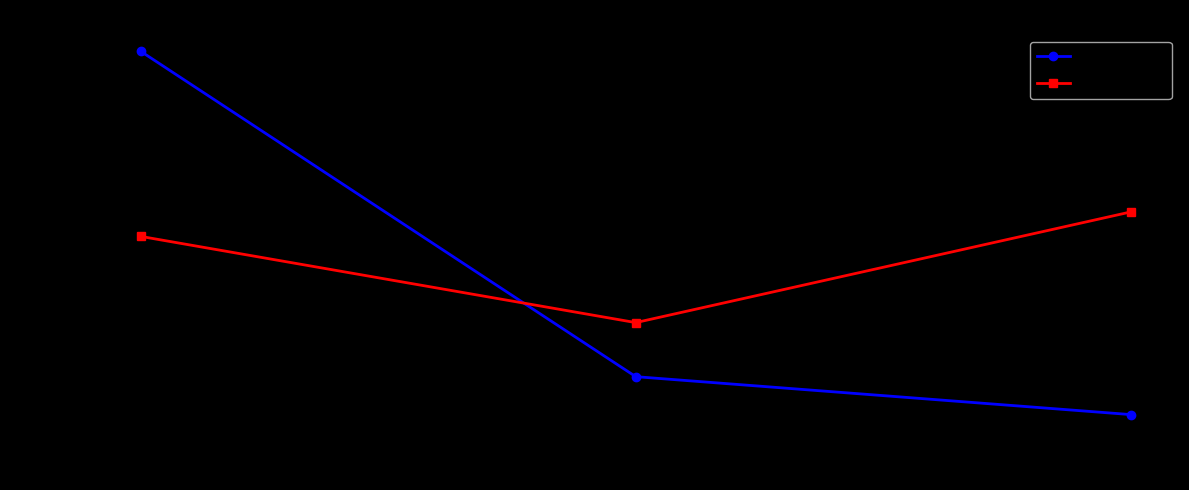


📊 Loss 그래프 저장: /content/drive/MyDrive/Patron/models/training_loss.png


In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(range(1, len(train_losses)+1), train_losses,
         marker='o', linewidth=2, label='Train Loss', color='blue')
plt.plot(range(1, len(val_losses)+1), val_losses,
         marker='s', linewidth=2, label='Val Loss', color='red')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training & Validation Loss (로컬 저장 최적화 버전)', fontsize=14, weight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_SAVE_PATH}/training_loss.png", dpi=150)
plt.show()

print(f"\n📊 Loss 그래프 저장: {MODEL_SAVE_PATH}/training_loss.png")

---

## 17. 최종 모델 저장

최종 Epoch의 가중치를 `resnet18_final.pth`로, 최적 모델은 이미 `best_model.pth`로 저장되어 있다. 두 파일을 함께 보관해 나중에 원하는 버전을 선택해 사용할 수 있다.

In [ ]:
torch.save(model.state_dict(), f"{MODEL_SAVE_PATH}/resnet18_final.pth")

print("="*60)
print("✅ 최종 모델 저장 완료")
print("="*60)
print(f"📁 저장 위치: {MODEL_SAVE_PATH}")
print(f"   - best_model.pth")
print(f"   - resnet18_final.pth")
print(f"   - training_loss.png")
print("="*60)

✅ 최종 모델 저장 완료
📁 저장 위치: /content/drive/MyDrive/Patron/models
   - best_model.pth
   - resnet18_final.pth
   - training_loss.png


---

# 🎉 완료!

## 📊 최종 결과 (2025-11-10 실행):
- **전처리**: 5시간 (이미지 추출)
- **학습**: 1.5시간 (Epoch 3개, Early Stopping)
- **총 시간**: 6.5시간 ⭐
- **Best Val Loss**: 0.005174 (Epoch 2)

## 🚀 핵심 최적화:
1. ✅ 로컬 저장으로 Google Drive I/O 병목 해결 (100배 빠름!)
2. ✅ Epoch 3개로 빠른 프로토타입
3. ✅ Batch 128로 GPU 메모리 활용
4. ✅ Semi-hard 샘플 3개로 I/O 최소화
5. ✅ Epoch 1-2: Random, 3: Semi-hard
6. ✅ Early Stopping으로 과적합 방지

## 📝 다음 단계:
- Phase 3: Faiss 인덱스 구축
- 유사 패턴 검색 시스템 구현

**모든 것이 로컬에서 작동합니다! 🔥**